# Data loading

This notebook loads the Letterboxd ratings (partial) dataset and inspects its structure. 
Initial steps include loading the dataset, inspecting its structure, and computing basic statistics. 

The goal of the notebook is understanding the dataset to prepare for predictive models.

## Dataset overview

In [41]:
import pandas as pd

In [42]:
ratings = pd.read_parquet("../data/raw/ratings.parquet")

In [43]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 10462257 entries, 0 to 10462256
Data columns (total 4 columns):
 #   Column    Dtype  
---  ------    -----  
 0   user      uint16 
 1   movie_id  uint32 
 2   title     str    
 3   rating    float32
dtypes: float32(1), str(1), uint16(1), uint32(1)
memory usage: 345.5 MB


In [44]:
ratings.head(5)

,user,movie_id,title,rating
0,0,1045381,scream-7,0.5
1,0,1090728,ella-mccay,4.0
2,0,977342,zootopia-2,3.5
3,0,871148,wicked-for-good,4.0
4,0,358757,now-you-see-me-now-you-dont-2025,4.0


In [45]:
ratings.shape

(10462257, 4)

In [46]:
ratings.columns

Index(['user', 'movie_id', 'title', 'rating'], dtype='str')

In [47]:
ratings.dtypes

user         uint16
movie_id     uint32
title           str
rating      float32
dtype: object

In [48]:
ratings["rating"].describe()

count    1.046226e+07
mean     3.283513e+00
std      1.055683e+00
min      5.000000e-01
25%      2.500000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [49]:
ratings["user"].nunique()

6519

In [50]:
ratings["movie_id"].nunique()

281045

The dataset contains ratings in the website Letterboxd of 6519 users of 281045 movies. 

There are over 10 million ratings recorded. This is a subset of the site but from the most popular users. 

For each rating we have information of the user, the name and id of the movie and a rating from 0.5 to 5.0. 

## Rating distribution

In [51]:
ratings["rating"].value_counts().sort_index()

rating
0.5     190095
1.0     361082
1.5     365872
2.0     859407
2.5     979630
3.0    1981222
3.5    1899613
4.0    2101217
4.5     875288
5.0     848831
Name: count, dtype: int64

In [52]:
import matplotlib.pyplot as plt

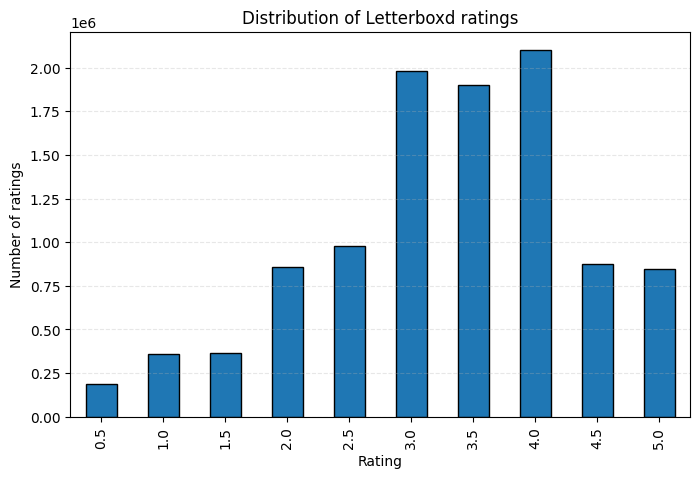

In [53]:
plt.figure(figsize=(8,5))

ratings["rating"].value_counts().sort_index().plot(kind="bar", color="tab:blue", edgecolor="black")

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of Letterboxd ratings")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

The distribution of the ratings shows a strong concentration in the region *3.0-4.0*. The mean is *3.28*. Very low ratings (under 2.0) are rare. 

There is a *positive rating bias*. Users are more likely to rate movies they enjoy or they expect to enjoy. 

The rating range is from *0.5 to 5.0 with increments of 0.5 points*. This gives us 10 possible values. For future modeling we will treat this metric as continuous for ease of use. 

## Most rated movies

In [54]:
ratings.groupby(["movie_id","title"]).size().sort_values(ascending=False).head(10)

movie_id  title                            
277064    barbie                               5541
426406    parasite-2019                        5218
353117    get-out-2017                         5110
475370    knives-out-2019                      5110
838140    the-substance                        5070
1116600   sinners-2025                         5031
474474    everything-everywhere-all-at-once    5007
371378    dune-2021                            4943
240344    la-la-land                           4927
348914    the-batman                           4891
dtype: int64

In [55]:
ratings.groupby(["movie_id","title"]).size().sort_values(ascending=False).head(10).sum()

np.int64(50848)

In [56]:
ratings.groupby(["movie_id","title"]).size().sort_values(ascending=False).head(1000).sum()/ratings["rating"].count()

np.float64(0.26016881443459094)

In [57]:
ratings.groupby("movie_id").size().describe()

count    281045.000000
mean         37.226270
std         205.902509
min           1.000000
25%           1.000000
50%           2.000000
75%           8.000000
max        5541.000000
dtype: float64

The dataset contains a small number of popular movies. Over *75%* of movies have 8 reviews or less. 

There 1000 most popular movies account for over *25%* of all the reviews. This shows a *popularity bias*. 

As a curiosity, all top ten movies are American but one which is Korean (Parasite). They are evenly distributed in terms of year of release: approx. one per year from 2016 to 2025. The average number of genres is 3 with 5 of them being comedies and 5 thrillers. 



## Most active users

In [58]:
ratings["user"].value_counts().head(10)

user
1917    9990
509     9952
4360    9896
1031    9793
2622    9642
595     9638
5829    9495
5694    9409
174     9376
2414    9355
Name: count, dtype: int64

In [59]:
ratings["user"].value_counts().describe()

count    6519.000000
mean     1604.886792
std      1517.398858
min        13.000000
25%       601.000000
50%      1092.000000
75%      2032.000000
max      9990.000000
Name: count, dtype: float64

The database is selected from the most popular users in the website. However, it is still visible the fact that a small number of users account for the vast majority of ratings. 

## Ratings per user distribution

In [60]:
rating_per_user = ratings.groupby("user").size()
rating_per_user.describe()

count    6519.000000
mean     1604.886792
std      1517.398858
min        13.000000
25%       601.000000
50%      1092.000000
75%      2032.000000
max      9990.000000
dtype: float64

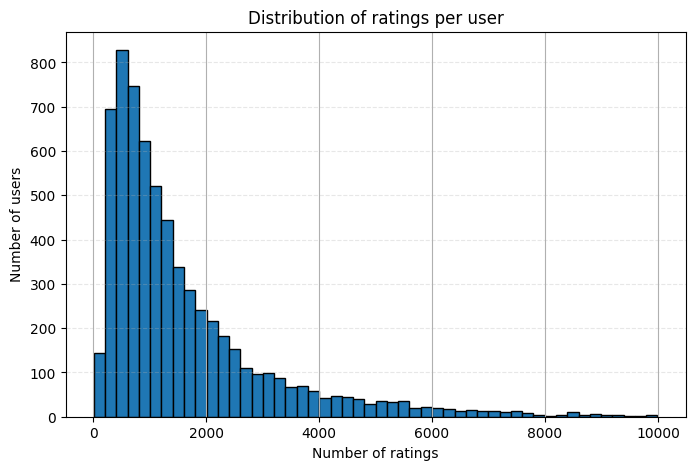

In [61]:
rating_per_user.hist(bins=50, edgecolor="black", figsize=(8,5))

plt.title("Distribution of ratings per user")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

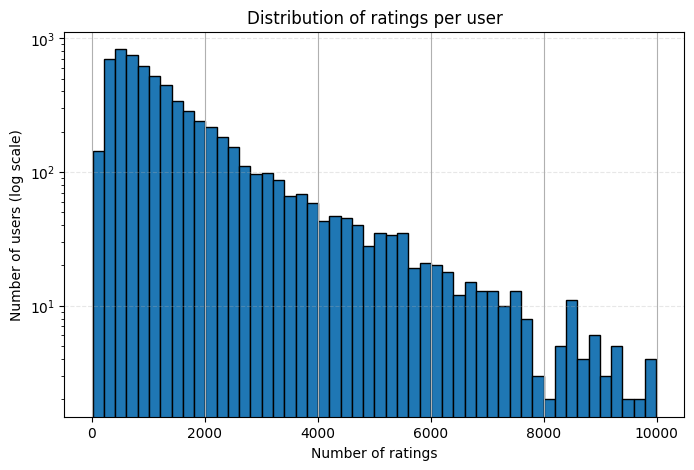

In [62]:
rating_per_user.hist(bins=50, edgecolor="black", figsize=(8,5))

plt.yscale("log")

plt.title("Distribution of ratings per user")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users (log scale)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

We observe that the ratings per user metric approximately follows an *exponential law*, since we see a line in a semilog plot. This means that the activity decerases rapidly with relatively few highly active users. 

User activity sometimes follows power laws that decay slower, but this data comes from a database that is biased: we only look at the most active users so we have actually flattened (a lot) the plot. In fact, that might be why we observe that dip in the first column. 

This type of bias is common in databases used in the movie industry where inactive users are removed to decrease sparsity. 

## Ratings per movie distribution

In [63]:
ratings_per_movie = ratings.groupby("movie_id").size()
ratings_per_movie.describe()

count    281045.000000
mean         37.226270
std         205.902509
min           1.000000
25%           1.000000
50%           2.000000
75%           8.000000
max        5541.000000
dtype: float64

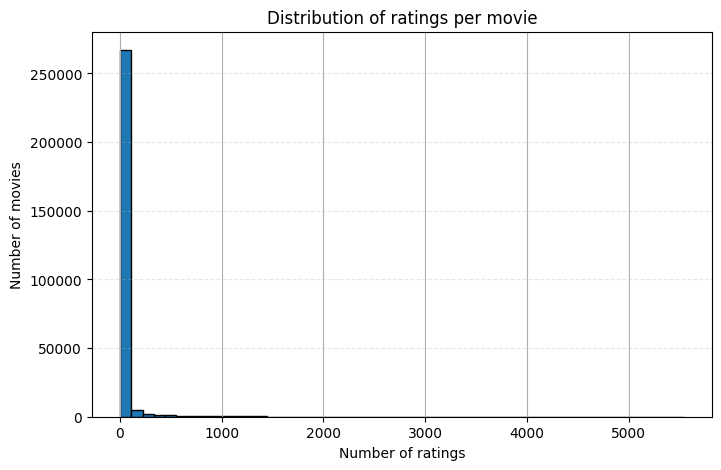

In [64]:
ratings_per_movie.hist(bins=50, edgecolor="black", figsize=(8,5))

plt.title("Distribution of ratings per movie")
plt.xlabel("Number of ratings")
plt.ylabel("Number of movies")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

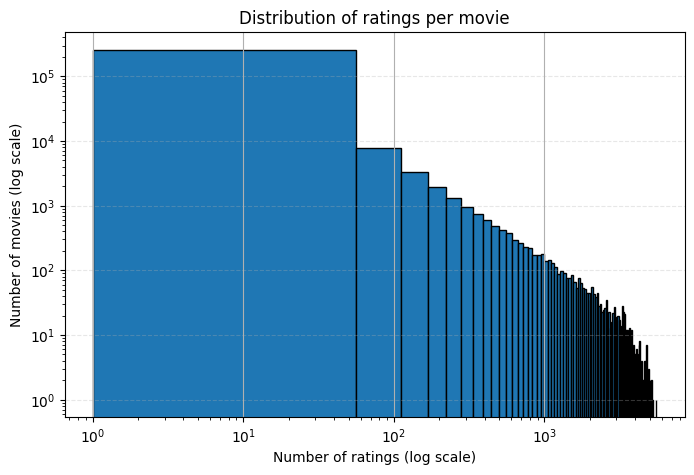

In [65]:
ratings_per_movie.hist(bins=100, edgecolor="black", figsize=(8,5))

plt.title("Distribution of ratings per movie")
plt.xlabel("Number of ratings (log scale)")
plt.ylabel("Number of movies (log scale)")

plt.xscale("log")
plt.yscale("log")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

Again, we observe a power law, in this case, the distribution of ratings per movie follows an even heavier tail as observed in the log scale. 

Most movies are only rated a handful of times and big blockbusters carry the majority of the ratings. 

## Popularity plot

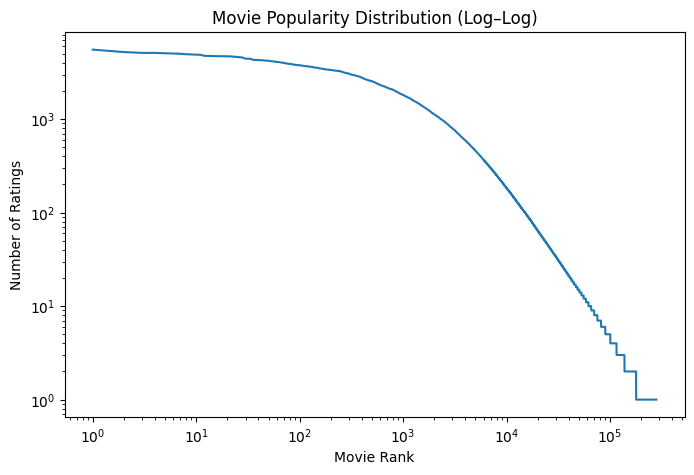

In [66]:
movie_popularity = ratings_per_movie.sort_values(ascending=False)
rank = range (1, len(movie_popularity)+1)

plt.figure(figsize=(8,5))
plt.plot(rank, movie_popularity.values)

plt.xscale("log")
plt.yscale("log")

plt.title("Movie Popularity Distribution (Log–Log)")
plt.xlabel("Movie Rank")
plt.ylabel("Number of Ratings")

plt.show()

We were expecting to observe a decreasing line since we believe that the popularity distribution also follows a power law but it seems that sampling from the most active users has introduced a bias. My guess is that because active users rate more, they also rate more obscure movies leaving us with a bias towards the tail of the distribution. 

Essentially, we are not observing the interactions of a random user but the interactions of the high degree nodes in the user graph. 

## Average movie rating

In [67]:
average_rating_per_movie = ratings.groupby(["movie_id", "title"])["rating"].mean()
average_rating_per_movie.head(10)

movie_id  title                                      
1         princesa                                       3.875000
6         every-sunday                                   3.100000
7         ghost-stories                                  2.800000
8         seconds-apart                                  2.750000
9         fertile-ground                                 1.607143
10        london-after-midnight                          3.076923
11        the-sword-and-the-rose                         2.833333
13        push                                           1.500000
14        linkin-park-live-from-madison-square-garden    5.000000
15        belladonna-of-sadness                          3.618351
Name: rating, dtype: float32

In [68]:
average_rating_per_movie.describe()

count    281045.000000
mean          2.935562
std           0.895820
min           0.500000
25%           2.500000
50%           3.000000
75%           3.500000
max           5.000000
Name: rating, dtype: float64

In [69]:
average_rating_per_movie.sort_values(ascending=False).head(10)

movie_id  title                                      
1245351   james-2024-1                                   5.0
417727    carsten-bang-alter-ego                         5.0
954729    pantomima                                      5.0
175129    woman-temptation                               5.0
32235     dream-theater-live-at-budokan                  5.0
954606    mystery-box-2022                               5.0
9452      barneys-christmas-star                         5.0
639498    slipknot-hellbound-2015                        5.0
116169    the-sisters-of-mercy-wake-in-concert-at-the    5.0
482638    el-ultimo-montonero                            5.0
Name: rating, dtype: float32

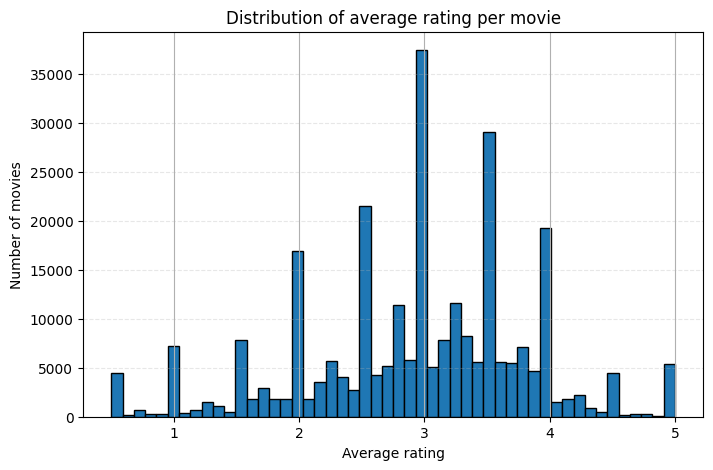

In [70]:
average_rating_per_movie.hist(bins=50, edgecolor="black", figsize=(8,5))    

plt.title("Distribution of average rating per movie")

plt.xlabel("Average rating")
plt.ylabel("Number of movies")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

We see the distribution of average ratigns per movie is skewed towards higher ratings. In particular,  it concentrates around 3. This reflects a common pattern in rating platforms where people tend to rate movies they like 

The high bars in the sequence 0.5, 1, 1.5, and other discrete rating levels can likely be attributed to lots of movies having very few ratings. When a movie has very few ratings, the average can only take a limited set of values corresponding to the discrete scale used in the site.  Many low-count movies produce the same repeated average, generating the spikes in hte histogram that we can see. 

## Rating variance 

In [71]:
rating_std_per_movie=ratings.groupby(["movie_id", "title"])["rating"].std()

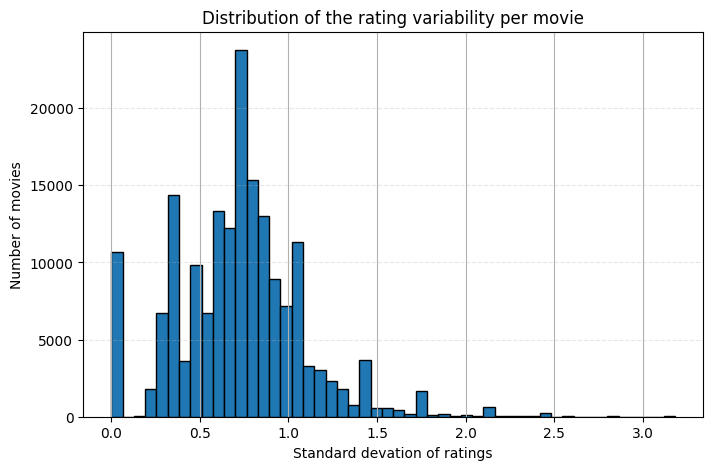

In [72]:
rating_std_per_movie.hist(bins=50, edgecolor="black", figsize = (8,5))

plt.title("Distribution of the rating variability per movie")

plt.xlabel("Standard devation of ratings")
plt.ylabel("Number of movies")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [73]:
popular_movies =ratings_per_movie[ratings_per_movie >= 50].index
filtered_ratings =ratings[ratings["movie_id"].isin(popular_movies)]
filtered_std_per_movie=filtered_ratings.groupby(["movie_id", "title"])["rating"].std()

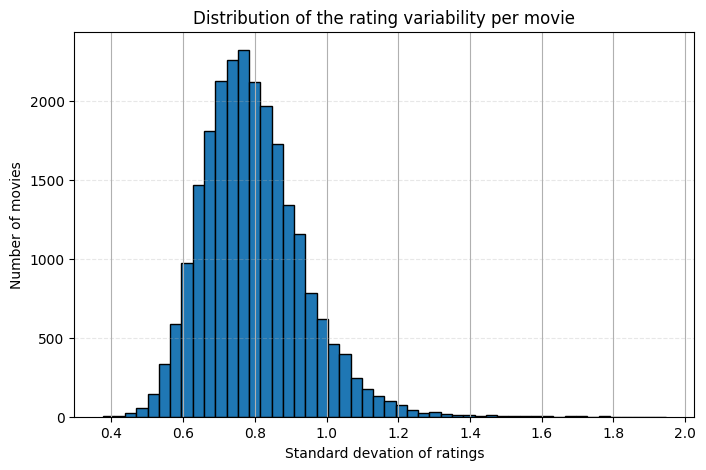

In [74]:
filtered_std_per_movie.hist(bins=50, edgecolor="black", figsize = (8,5))

plt.title("Distribution of the rating variability per movie")

plt.xlabel("Standard devation of ratings")
plt.ylabel("Number of movies")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

We analyze the distribution of the standard deviation of ratings per movie. This quantity measures how much users disagree on a movie: a higher standard deviation indicates more variablity of opinions. 

Before filtering, the distribution contains many irregular values. We can see that the first graph is not smooth. This happens because many movies only have a handful of ratings or less. In those cases, the standard deviation can take extreme values. 

After filtering movies with fewer than 50 ratings, the distribution becomes smoother and more concentrated. This makes the data more reliable. 

The distribution of the rating standard deviation appears roughly bell-shaped. This indicated that most movies receive a moderate level of agreement among users. The standard deviation concentrates around 0.68 and 0.81 approximately. 


## Movie statistics table

In [75]:
movie_stats=ratings.groupby(["movie_id", "title"])["rating"].agg(["count", "mean", "std"])
movie_stats.head(10)

,,count,mean,std
movie_id,title,,,
1,princesa,4,3.875000,0.478714
6,every-sunday,5,3.100000,0.223607
7,ghost-stories,5,2.800000,0.670820
8,seconds-apart,24,2.750000,0.944089
9,fertile-ground,14,1.607143,0.902530
10,london-after-midnight,13,3.076923,0.534094
11,the-sword-and-the-rose,6,2.833333,0.683130
13,push,1,1.500000,NaN
14,linkin-park-live-from-madison-square-garden,1,5.000000,NaN


## Funnel Visualization

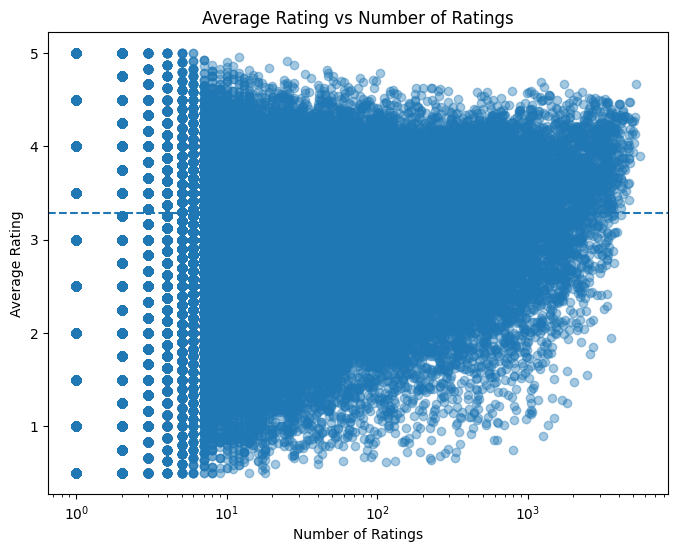

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(movie_stats["count"], movie_stats["mean"], alpha=0.4)

plt.xscale("log")

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Number of Ratings")

C = ratings["rating"].mean()
plt.axhline(C, linestyle="--")

plt.show()

Movies with few ratings show a large spread in average scores, while movies with many ratings tend to concentrate near the global mean (3.28). This funnel-shaped pattern reflects statistical variability in small samples.

There is also a slight upwards trend that suggests that more frequently rated movies tend to have higher average scores, reflecting popularity and selection bias (people tend to rate the most popular movies higher and people tend to watch and rate better rated movies) in user score. 

In [83]:
movie_stats["count"].corr(movie_stats["mean"])

np.float64(0.07022417334357178)

In [84]:
movie_stats[["count", "mean"]].corr()

,count,mean
count,1.000000,0.070224
mean,0.070224,1.000000


However, the correlation is very low, 0.07 meaning that there is no linear relationship between the rating of the movie and how many people have rated it. Meaning that in this case, popular movies are not systematically rated higher. 

More research needs to be done to decide why it tilts upwards. 

## Top ten movies

In [77]:
popular_movies = movie_stats[movie_stats["count"] >= 50]
popular_movies.sort_values("mean", ascending=False).head(10)

,,count,mean,std
movie_id,title,,,
1315335,lady-gaga-mayhem-on-the-beach,104,4.783654,0.626147
1089526,twinkling-watermelon,51,4.754902,0.541964
871476,the-trial-2017-2,76,4.730263,0.613410
1435007,taylor-swift-the-eras-tour-the-final-show,94,4.712766,0.720250
1331311,when-life-gives-you-tangerines-2025,98,4.704082,0.641506
677811,veneno-2020,57,4.701755,0.618608
780824,9-11-one-day-in-america,51,4.696078,0.375212
1188092,the-pop-out-ken-friends,80,4.693750,0.548264
424054,twin-peaks-the-return,1214,4.691927,0.651133


The top ten best rated movies seem to be dominated by concert films and miniserise. 

The concert films from pop artists (Lady Gaga, Taylor Swift, Alice in Chains, The poop out Ken Friends) is very likely because these artists have a loyal following that will watch and highly rate the movies and average users may not watch or rate them at all. 

The miniseries or TV shows (Veneno, Twin Peaks, When life gives you tangerines, 9/11, Twinklin Watermelon) also tend to have higher ratings because less people tend to watch them and rate them since they are longer. Also, the website is centered around films so people might not even know that miniseries are in Letterboxd or they might not care about them. 

Most movies have relatively few ratings with the exception of Twin Peaks, The Return. This is because this movie has many more ratings than the rest, so it's avergae is more accurate representative of an average viewer and not just a fan.

To correct this niche audience bias is why Letterboxd calculated the ratign as a weighted average (the formula is not public).

## Compute the weighted ratings

We will attempt to correct the niche-content bias by calculating a weighted average. If the movie has many ratings, then we will keep approximately the regular average. If the movie has only a few more ratings than the minimum threshold (50), then we will compensate the regular average by balancing it with the total average of all movies. This will tame the effect that a loyal fanbase creates. 

In [78]:
C = ratings["rating"].mean()
R = popular_movies["mean"]
v = popular_movies["count"]
m = 50 
movie_stats["weighted_average"] = (v / (v + m)) * R + (m / (m + v)) * C
movie_stats.sort_values("weighted_average", ascending=False).head(10)

,,count,mean,std,weighted_average
movie_id,title,,,,
426406,parasite-2019,5218,4.665868,0.547826,4.652748
424054,twin-peaks-the-return,1214,4.691927,0.651133,4.636215
51700,12-angry-men,1721,4.666763,0.542464,4.627711
384557,twin-peaks,1268,4.636436,0.539956,4.585111
51818,the-godfather,2277,4.585639,0.675747,4.557660
37004,stop-making-sense,1046,4.597514,0.642255,4.537569
51816,the-godfather-part-ii,1884,4.569798,0.662144,4.536544
51716,seven-samurai,1012,4.584486,0.625478,4.523235
43015,harakiri,784,4.594388,0.581225,4.515798


Comparing the two top ten rankings, clearly the weighted ranking is closer to what we expect a ranking of the best 10 movies to be. Some movies generally regarded as classics that are in the second ranking are: The Godfather I and II , 12 Angry Men, and Parasite. 

The only movie that appears in both rankings is Twin Peaks: The Return that, as we explained before, has a lot of ratings and therefore, its average rating nad weighted rating should be high and similar. 

Although the formula for Letterboxd's weighted average is not known some clues can be taken from the paper: "Behind the Stars: Uncovering Hidden Adjustments in Letterboxd Film Ratings", 2025. We will try to reverse engineer the formula is an upcoming report. 

## Most controversial movies

In [79]:
popular_movies.sort_values("std", ascending=False).head(10)

,,count,mean,std
movie_id,title,,,
234277,love-on-a-leash,188,2.382979,1.947061
253003,cool-cat-saves-the-kids,145,2.051724,1.862201
40988,the-room,1461,2.302190,1.809475
425735,twisted-pair,159,2.396226,1.788744
957761,cade-the-tortured-crossing,81,3.037037,1.777951
141866,fateful-findings,340,2.205882,1.759163
309183,pass-thru,101,2.475248,1.749823
2023,after-last-season,86,1.947674,1.726999
81616,i-am-herenow,131,2.282443,1.707561


This list is filled with cult classics of the type it's so bad that it's good (The Room, Cool Cat Saves the Kids, Love on a Leash, Fateful Findings). Some people watch them seriously and finds them terrible, and some people watch them ironically and rate them highly. 

## Summary

The exploratory analysis reveals several characteristic patterns of online rating datasets. User activity and movie popularity exhibit highly skewed distributions, with a small number of highly active users and very popular movies accounting for a large fraction of ratings.

Filtering movies with few ratings improves the reliability of estimated statistics such as the mean rating and rating variability.

Finally, analyzing movie-level statistics allows us to identify widely loved movies as well as controversial ones that generate strong disagreement among viewers.